In [2]:
%pip install matplotlib
%pip install numpy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
image = cv2.imread("../images/giraffe-Kenya.png")

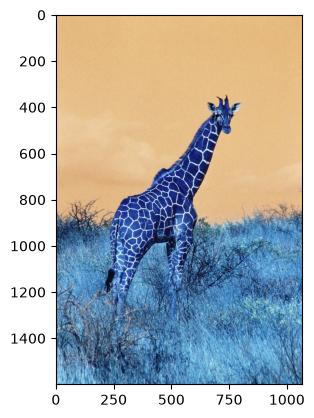

In [5]:
plt.imshow(image)
# see openCV by default use BGR image store

In [6]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

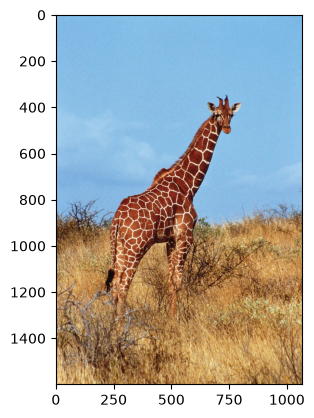

In [7]:
plt.imshow(image_rgb)

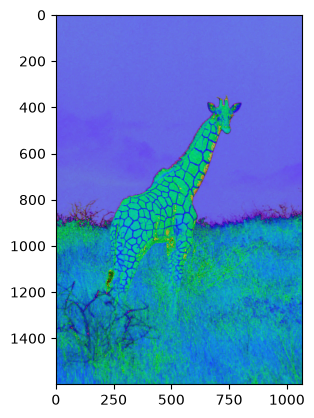

In [8]:
plt.imshow(image_hsv)

In [9]:
# lets target girraf patch i.e white
# so we need to give white color upper and lower bound
lower_white = np.array([0,0,190]) #([h,s,v]) -> hue, saturation, brightness
upper_white = np.array([30,80,255])

In [10]:
mask = cv2.inRange(image_hsv, lower_white, upper_white)

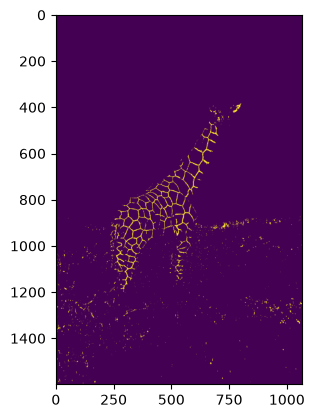

In [11]:
plt.imshow(mask)

### here mask have vilolet and yellow color as its matplotlib , if show show using openCV its black and white

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1600, 1067), dtype=uint8)

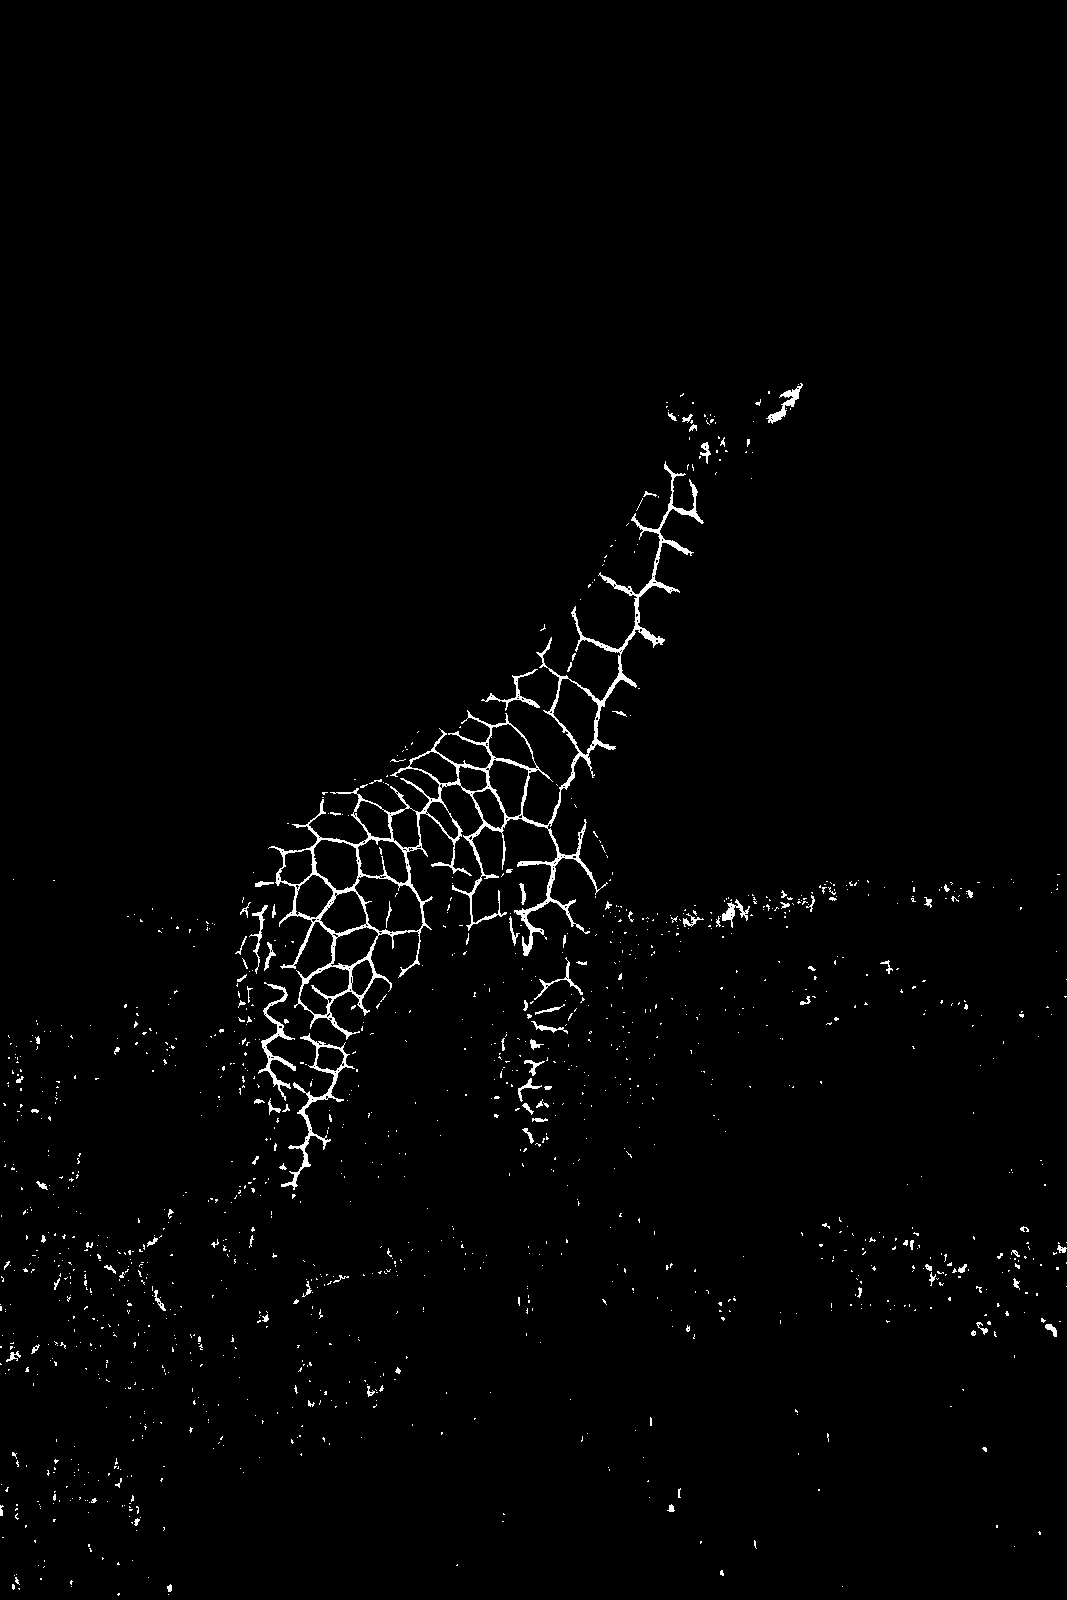

In [12]:
from IPython.display import Image, display
display(mask)

if image is None:
    print("Error: Could not load the image.")
else:
    _, buffer = cv2.imencode(".jpg", mask)
    # display(Image(data=buffer.tobytes()))

openCV_mask=display(Image(data=buffer.tobytes()))

In [13]:
# lets target black color
black_hsv = np.uint8([[[120, 255, 0]]])
#now convert black_hsv to BGR as openCV take BGR format
black_bgr = cv2.cvtColor(black_hsv, cv2.COLOR_HSV2BGR)[0][0]

In [14]:
image_result = image.copy()
#now if mask>0 then change with black bgr otherwise original image
image_result[mask>0] = black_bgr

In [15]:
image_result_rgb = cv2.cvtColor(image_result, cv2.COLOR_BGR2RGB)

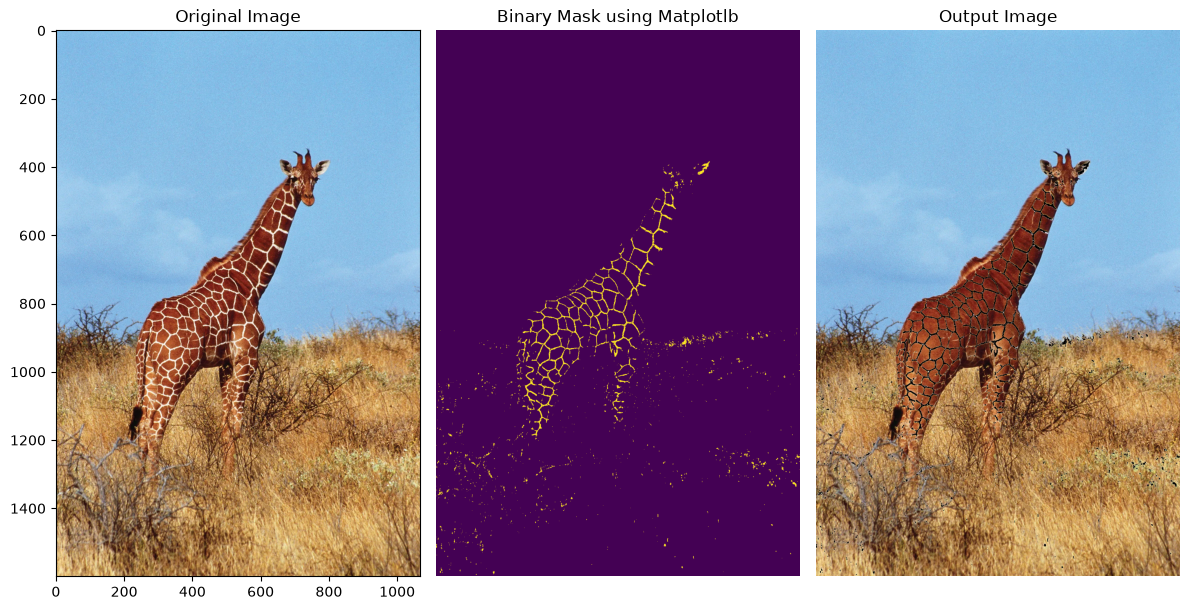

In [16]:
# PLOT

fig, axs = plt.subplots(1,3, figsize=(12,6))

axs[0].imshow(image_rgb)
axs[0].set_title("Original Image")
axs[0].axis('ON')

axs[1].imshow(mask)
axs[1].set_title("Binary Mask using Matplotlb")
axs[1].axis('off')


axs[2].imshow(image_result_rgb)
axs[2].set_title("Output Image")
axs[2].axis('off')

plt.tight_layout()
plt.show()